In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
'''import os
import shutil
import random

# Set your source and destination paths
source_dir = 'D:\DataSets\Eye_Project'
dest_dir = 'D:\DataSets\Split_Eye_Project'

# Categories
categories = ['closed_eye', 'open_eye']

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create destination folders
for split in ['train', 'val', 'test']:
    for category in categories:
        os.makedirs(os.path.join(dest_dir, split, category), exist_ok=True)

# Split the data
for category in categories:
    img_dir = os.path.join(source_dir, category)
    images = os.listdir(img_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split, split_images in splits.items():
        for img in split_images:
            src_path = os.path.join(img_dir, img)
            dst_path = os.path.join(dest_dir, split, category, img)
            shutil.copy2(src_path, dst_path)

print("✅ Dataset successfully split into train, val, and test folders.")
'''

✅ Dataset successfully split into train, val, and test folders.


In [2]:
# Base path
dataset_path = 'D:\DataSets\Split_Eye_Project'

# 1. Training Data Generator (with slight augmentation)
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
).flow_from_directory(
    dataset_path + '/train',
    target_size=(64,64),
    color_mode='grayscale',
    class_mode='binary',

    batch_size=32,
    shuffle=True
)

# 2. Validation Data Generator (no augmentation)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    dataset_path + '/val',
    target_size=(64,64),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

# 3. Test Data Generator (no augmentation)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    dataset_path + '/test',
    target_size=(64,64),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)


Found 33600 images belonging to 2 classes.
Found 7200 images belonging to 2 classes.
Found 7200 images belonging to 2 classes.


In [4]:
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Optional: 3rd Conv Layer (only if needed later)
# model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))  # Dropout to reduce overfitting

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))


In [5]:
model.compile(
    loss='binary_crossentropy',     # Because it's a 2-class problem
    optimizer='adam',               # Popular and efficient optimizer
    metrics=['accuracy']            # To track accuracy during training
)


In [6]:
history=model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10


1050/1050 [==============================] - 256s 243ms/step - loss: 0.2887 - accuracy: 0.8773 - val_loss: 0.1353 - val_accuracy: 0.9479
Epoch 2/10
1050/1050 [==============================] - 49s 47ms/step - loss: 0.1901 - accuracy: 0.9279 - val_loss: 0.1094 - val_accuracy: 0.9614
Epoch 3/10
1050/1050 [==============================] - 49s 47ms/step - loss: 0.1504 - accuracy: 0.9451 - val_loss: 0.0808 - val_accuracy: 0.9706
Epoch 4/10
1050/1050 [==============================] - 49s 47ms/step - loss: 0.1280 - accuracy: 0.9545 - val_loss: 0.0681 - val_accuracy: 0.9781
Epoch 5/10
1050/1050 [==============================] - 50s 47ms/step - loss: 0.1129 - accuracy: 0.9587 - val_loss: 0.0523 - val_accuracy: 0.9814
Epoch 6/10
1050/1050 [==============================] - 49s 47ms/step - loss: 0.1076 - accuracy: 0.9618 - val_loss: 0.0533 - val_accuracy: 0.9853
Epoch 7/10
1050/1050 [==============================] - 50s 48ms/step - loss: 0.0948 - accuracy: 0.9663 - val_loss: 0.04

In [7]:
model.evaluate(test_gen)


225/225 [==============================] - 37s 164ms/step - loss: 0.0354 - accuracy: 0.9893


[0.035444457083940506, 0.9893055558204651]

In [8]:
model.save("bigger_eye_state_model.keras")

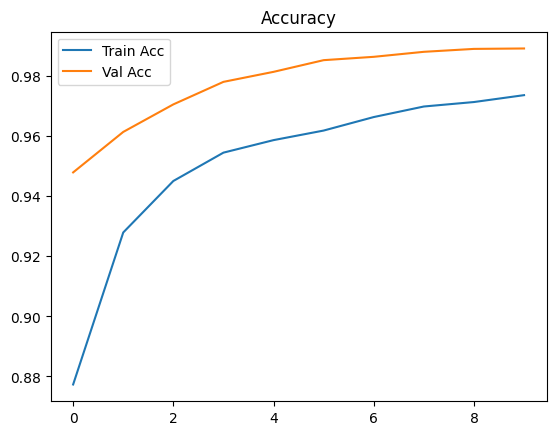

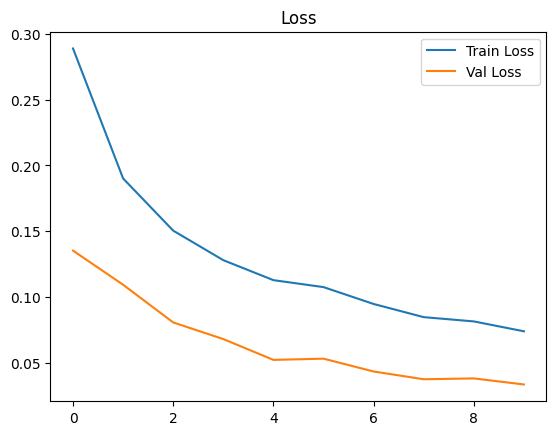

In [9]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()
